In [1]:
import pandas as pd

dataset = pd.read_csv(filepath_or_buffer="../bank-full.csv", sep=';')
dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [2]:
features = dataset.columns
data_types = dataset.dtypes
dataset_info = dataset.info()
print(dataset.isnull().sum())
print(dataset.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      

In [3]:
# Plotter functions for data exploratory
def box_plot(feature_col, outcome_col, title=""):
    assert len(feature_col) == len(outcome_col)
    groups = [g.values for _, g in feature_col.groupby(outcome_col)]
    labels = list(feature_col.groupby(outcome_col).groups.keys())

    plt.figure(figsize=(8, 6))
    plt.boxplot(groups, tick_labels=labels)
    plt.title(title)
    plt.ylabel(feature_col.name)
    plt.xlabel(outcome_col.name)
    plt.show()

def histogram_plot(feature):
    plt.hist(feature)
    plt.show()

def scatter_plot(feature1, feature2):
    assert len(feature1) == len(feature2)
    plt.scatter(feature1, feature2)
    plt.show()

def categorical_plot(categories, rates, title):
    plt.figure()
    plt.bar(categories, rates)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

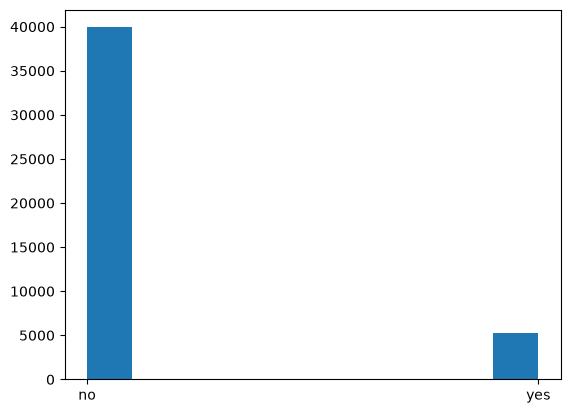

In [4]:
# 1. What we predict? Plot Y distribution first
from matplotlib import pyplot as plt

histogram_plot(dataset.y)

In [5]:
# We see heavy class imbalance. Elements of 'no' is around 40000, meanwhile 'yes' is around 5000. We need to pay attention to this.

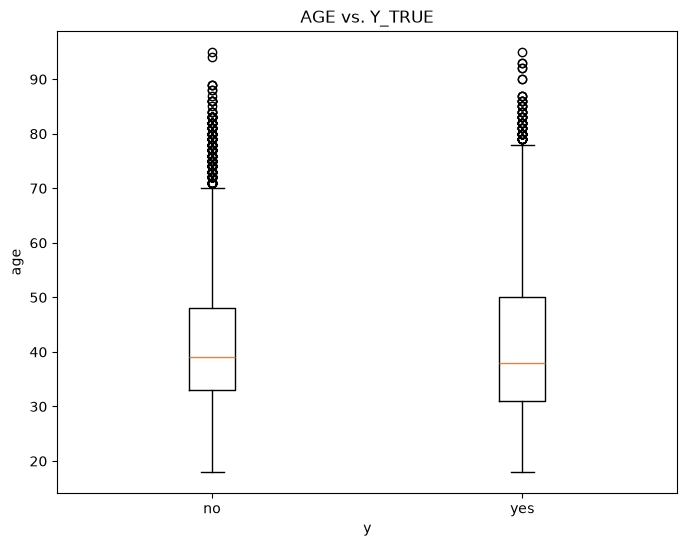

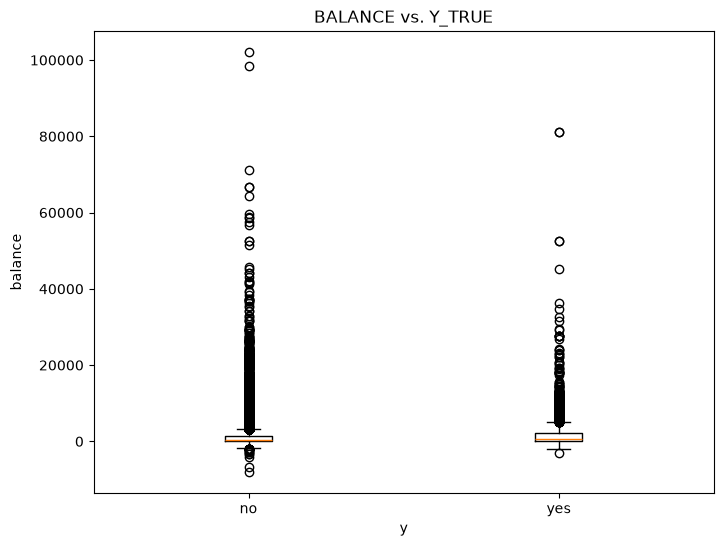

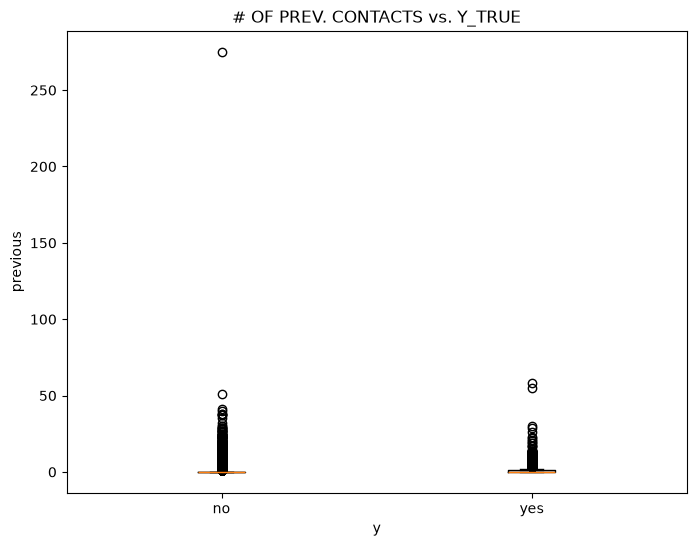

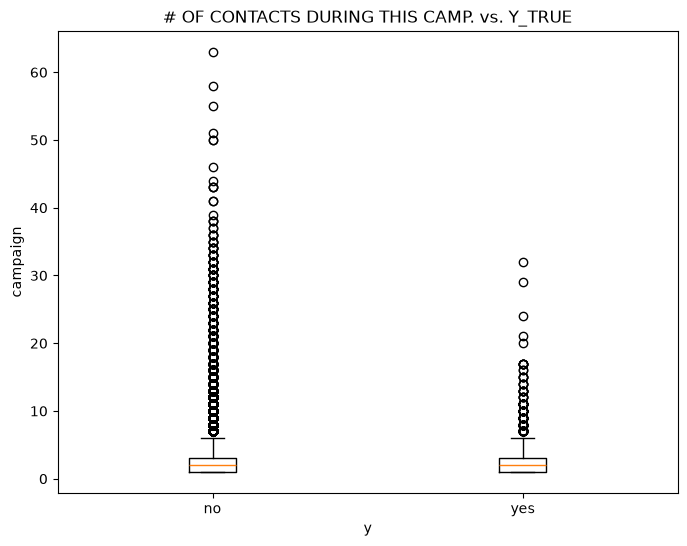

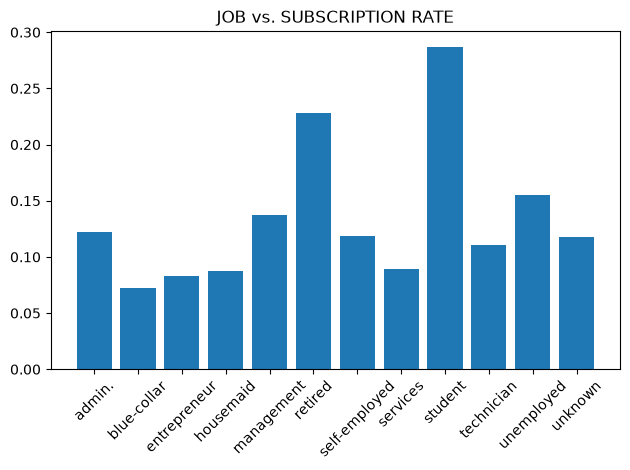

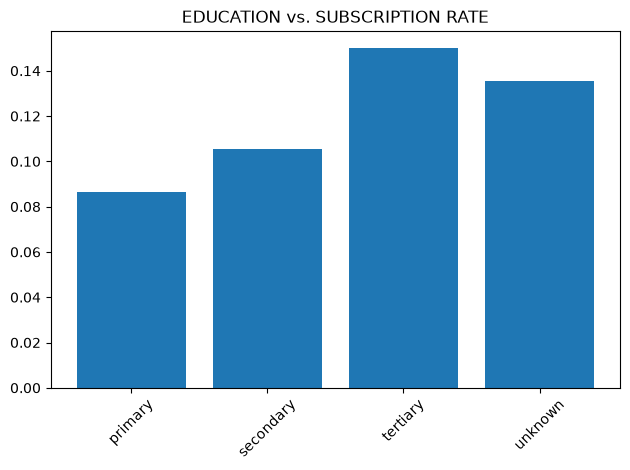

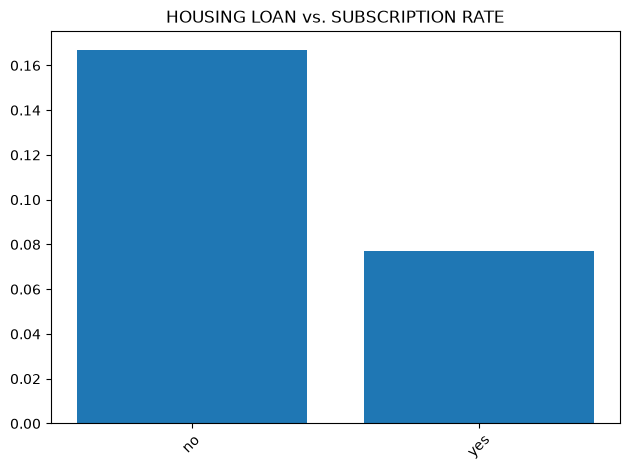

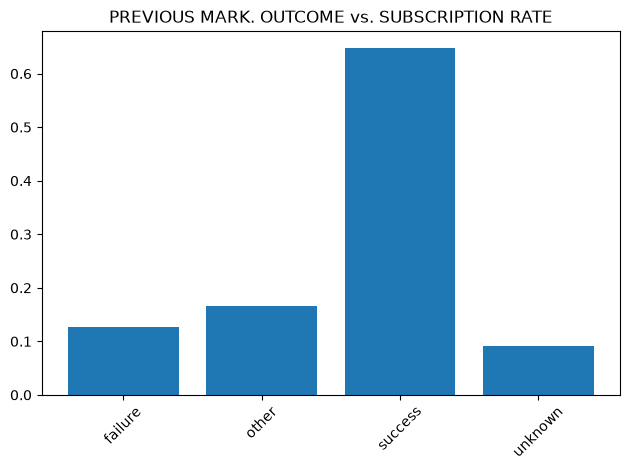

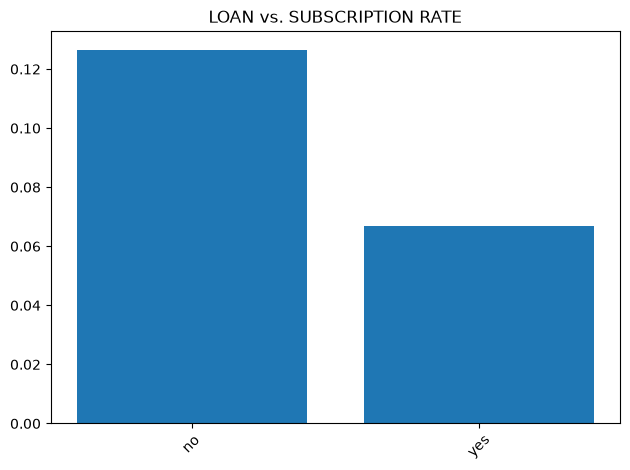

In [6]:
# 2. plot feature relationship to Y/target
box_plot(dataset.age, dataset.y, "AGE vs. Y_TRUE")
box_plot(dataset.balance, dataset.y, "BALANCE vs. Y_TRUE")
box_plot(dataset.previous, dataset.y, "# OF PREV. CONTACTS vs. Y_TRUE")
box_plot(dataset.campaign, dataset.y, "# OF CONTACTS DURING THIS CAMP. vs. Y_TRUE")


# Categorical plots:
# JOB
dataset["y_numeric"] = (dataset["y"] == "yes").astype(int)
grouped = dataset.groupby("job")
rates = grouped["y_numeric"].mean()
categorical_plot(rates.index, rates.values, "JOB vs. SUBSCRIPTION RATE")

# Education
grouped = dataset.groupby("education")
rates = grouped["y_numeric"].mean()
categorical_plot(rates.index, rates.values, "EDUCATION vs. SUBSCRIPTION RATE")

# Housing
grouped = dataset.groupby("housing")
rates = grouped["y_numeric"].mean()
categorical_plot(rates.index, rates.values, "HOUSING LOAN vs. SUBSCRIPTION RATE")

# Previous marketing outcome:
grouped = dataset.groupby("poutcome")
rates = grouped["y_numeric"].mean()
categorical_plot(rates.index, rates.values, "PREVIOUS MARK. OUTCOME vs. SUBSCRIPTION RATE")

# Personal Loan:
grouped = dataset.groupby("loan")
rates = grouped["y_numeric"].mean()
categorical_plot(rates.index, rates.values, "LOAN vs. SUBSCRIPTION RATE")




In [7]:
# AGE vs. Y:
# Age distribution overlaps, therefore the age alone is not enough.

# 

In [8]:
# 3. Drop features
# We can see the phone duration feature for example. This is unknown for us in the next prediction time. If we use this we can easily introduce
# data leakage to our training.

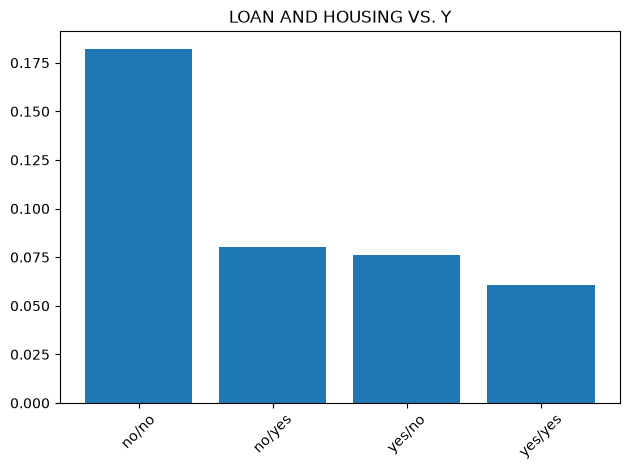

In [9]:
# 4. Feature vs. Feature plots
# Split the dataset into loan and housing groups, select their binary subscription outcome and calculate the subscription ratio.
grouped = dataset.groupby(["loan", "housing"])
rates = grouped["y_numeric"].mean()
categories = ["/".join(r) for r in rates.index]
categorical_plot(categories, rates.values, "LOAN AND HOUSING VS. Y")


In [10]:
# We see that with no loan and no mortgage, people tend to have subscription. But we need the sample size, therefore instead of mean, 
# I'm going to use size() to tell how many customers within each group. Then check how many actually subscribed with sum().

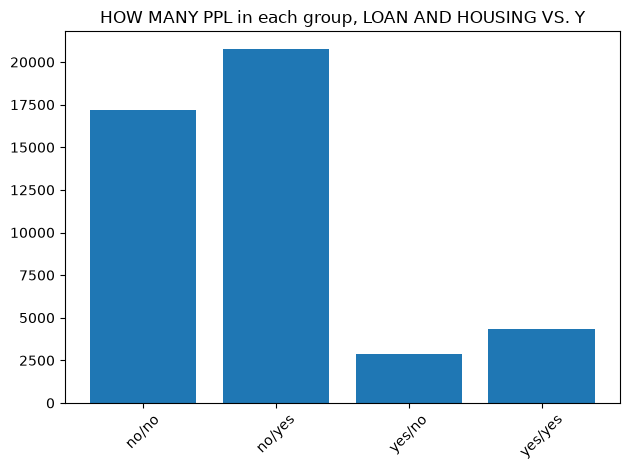

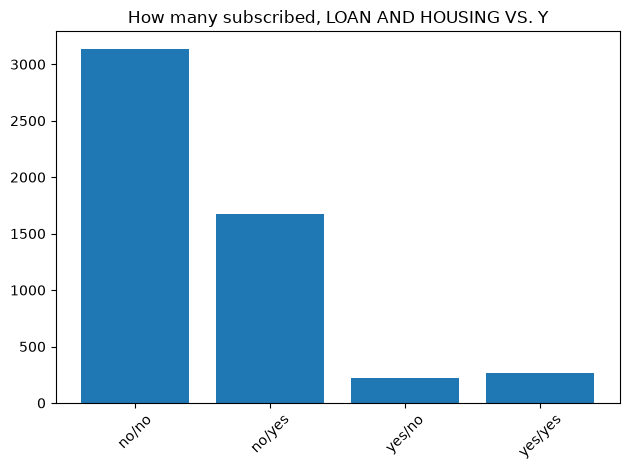

In [11]:
grouped = dataset.groupby(["loan", "housing"])
rates = grouped["y_numeric"].size()
categories = ["/".join(r) for r in rates.index]
categorical_plot(categories, rates.values, "HOW MANY PPL in each group, LOAN AND HOUSING VS. Y")

rates = grouped["y_numeric"].sum()
categories = ["/".join(r) for r in rates.index]
categorical_plot(categories, rates.values, "How many subscribed, LOAN AND HOUSING VS. Y")


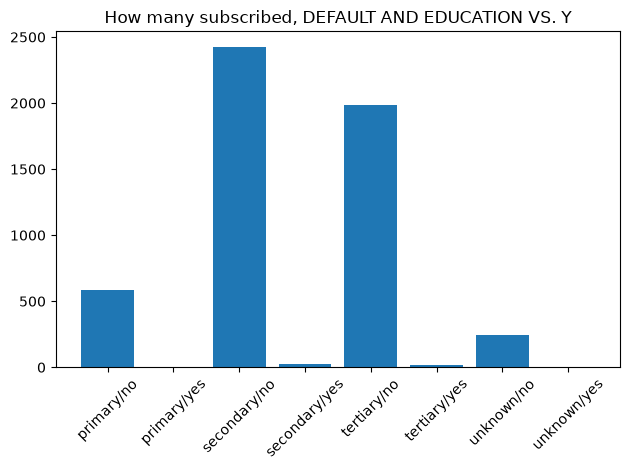

In [12]:
# Lets see how many people defaulted and whats their education who subscribed.
grouped = dataset.groupby(["education", "default"])
rates = grouped["y_numeric"].sum()
categories = ["/".join(r) for r in rates.index]
categorical_plot(categories, rates.values, "How many subscribed, DEFAULT AND EDUCATION VS. Y")
